<a href="https://colab.research.google.com/github/satwikacandy012-tech/data-analytics-projects/blob/main/Satwika_Copy_of_GroupProject_BLSReports_sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Class Name** - DSC 785-001 - Spring 2026: Text Analytics

**Assignment Name** :Final Group Project

**Business Question** - How does the language used in U.S. Bureau of Labor Statistics
employment reports reflect real labor market conditions over time?


**Author(s)** - Team Members – Mohammed Amaan Qureshi, Satwika Kondadasula, Mrudhula Duduka, Sai Venkata Prashanth Varma Namburi,

**Mail Id** - saivenkataprashant@mail.adelphi.edu Date Of Creation - 03/10/2026

In [ ]:
!pip install pandas nltk pdfplumber scikit-learn matplotlib seaborn wordcloud textblob pandas_datareader beautifulsoup4 networkx

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


In [ ]:
folder="/content/drive/MyDrive/Text Analytics Bls Reports Group Project/bls_reports"



In [ ]:
import os
import pdfplumber
import pandas as pd
from tqdm import tqdm  # progress bar

pdf_folder = '/content/drive/MyDrive/Text Analytics Bls Reports Group Project/bls_reports'  # location of the folder conatining the data pdfs

pdf_files = [f for f in os.listdir(pdf_folder) if f.endswith('.pdf')]
print(f"Found {len(pdf_files)} PDFs")


def extract_pdf_text(file_path):                                                            #extracting text from pdf
    with pdfplumber.open(file_path) as pdf:
        text = ''
        for page in pdf.pages:
            text += page.extract_text() + ' '
    return text


reports = []
months = []

for file in tqdm(pdf_files, desc="Loading PDFs"):
    file_path = os.path.join(pdf_folder, file)
    try:
        text = extract_pdf_text(file_path)
        reports.append(text)
        months.append(file.replace('.pdf',''))                                   # we are using simple month identifier
    except:
        reports.append('')
        months.append(file.replace('.pdf',''))
df = pd.DataFrame({'month': months, 'report_text': reports})
print(df.head())

Found 121 PDFs


Loading PDFs: 100%|██████████| 121/121 [16:33<00:00,  8.21s/it]

             month                                        report_text
0  empsit_02052016  Transmission of material in this release is em...
1  empsit_03042016  Transmission of material in this release is em...
2  empsit_04012016  Transmission of material in this release is em...
3  empsit_05062016  Transmission of material in this release is em...
4  empsit_06032016  Transmission of material in this release is em...


In [ ]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = text.lower()
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return ' '.join(words)

df['clean_text'] = df['report_text'].apply(clean_text)
print(df[['month','clean_text']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


             month                                         clean_text
0  empsit_02052016  transmission material release embargoed usdl e...
1  empsit_03042016  transmission material release embargoed usdl e...
2  empsit_04012016  transmission material release embargoed usdl e...
3  empsit_05062016  transmission material release embargoed usdl e...
4  empsit_06032016  transmission material release embargoed usdl e...


In [ ]:

from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))


bls_stopwords = [
    'transmission', 'material', 'release', 'embargoed', 'usdl',
    'information', 'contact', 'office', 'report', 'preliminary'
]

stop_words.update(bls_stopwords)


In [ ]:
from nltk.stem import WordNetLemmatizer
import re

lemmatizer = WordNetLemmatizer()

def clean_bls_text(text):                                                       # Lowercase and remove numbers/punctuation

    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text)


    words = text.split()                                                         # Tokenize


    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]      # Remove stopwords + lemmatize

    return ' '.join(words)

df['clean_text'] = df['report_text'].apply(clean_bls_text)

In [ ]:
from collections import Counter
all_words = ' '.join(df['clean_text']).split()
Counter(all_words).most_common(50)

[('survey', 11162),
 ('employment', 10477),
 ('data', 7681),
 ('establishment', 7632),
 ('household', 7270),
 ('unemployed', 7017),
 ('employed', 6136),
 ('table', 5871),
 ('p', 5830),
 ('toyears', 5808),
 ('industry', 5082),
 ('estimate', 4972),
 ('percent', 4681),
 ('civilianlaborforce', 4505),
 ('payroll', 4396),
 ('participationrate', 4384),
 ('employmentpopulationratio', 4384),
 ('unemploymentrate', 4384),
 ('month', 4029),
 ('may', 3957),
 ('nonfarm', 3931),
 ('unemployment', 3838),
 ('adjusted', 3828),
 ('employee', 3588),
 ('job', 3535),
 ('change', 3511),
 ('seasonally', 3098),
 ('hour', 3096),
 ('sample', 3035),
 ('june', 2924),
 ('labor', 2823),
 ('july', 2800),
 ('notinlaborforce', 2783),
 ('jan', 2732),
 ('person', 2714),
 ('feb', 2680),
 ('worker', 2661),
 ('dec', 2631),
 ('nov', 2604),
 ('apr', 2553),
 ('manufacturing', 2544),
 ('mar', 2529),
 ('aug', 2516),
 ('business', 2508),
 ('oct', 2448),
 ('civiliannoninstitutionalpopulation', 2448),
 ('b', 2367),
 ('sept', 2336),

In [ ]:
import re
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

def clean_bls_text_final(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)  # remove punctuation
    text = re.sub(r'\d+', '', text)       # remove numbers
    text = re.sub(r'\s+', ' ', text)      # normalize spaces

    # Tokenize
    words = text.split()

    # Remove stopwords + lemmatize
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]

    return ' '.join(words)
df['clean_text'] = df['report_text'].apply(clean_bls_text_final)

In [ ]:
from collections import Counter
all_words = ' '.join(df['clean_text']).split()
Counter(all_words).most_common(20)

[('survey', 11162),
 ('employment', 10477),
 ('data', 7681),
 ('establishment', 7632),
 ('household', 7270),
 ('unemployed', 7017),
 ('employed', 6136),
 ('table', 5871),
 ('p', 5830),
 ('toyears', 5808),
 ('industry', 5082),
 ('estimate', 4972),
 ('percent', 4681),
 ('civilianlaborforce', 4505),
 ('payroll', 4396),
 ('participationrate', 4384),
 ('employmentpopulationratio', 4384),
 ('unemploymentrate', 4384),
 ('month', 4029),
 ('may', 3957)]

In [ ]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

# Standard stopwords
stop_words = set(stopwords.words('english'))

# Custom BLS boilerplate words
bls_stopwords = [
    'survey','employment','data','establishment','household','unemployed','employed',
    'table','p','toyears','industry','estimate','percent','civilianlaborforce','payroll',
    'participationrate','employmentpopulationratio','unemploymentrate','month','may',
    'june','july','jan','feb','mar','apr','aug','sept','oct','nov','dec',
    'adjusted','nonfarm','employee','job','change','seasonally','hour','sample',
    'labor','notinlaborforce','person','worker','manufacturing','business',
    'civiliannoninstitutionalpopulation','force','b'
]

stop_words.update(bls_stopwords)
lemmatizer = WordNetLemmatizer()

def clean_bls_text_final(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)  # remove punctuation
    text = re.sub(r'\d+', '', text)      # remove numbers
    text = re.sub(r'\s+', ' ', text)     # normalize spaces
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return ' '.join(words)

df['clean_text'] = df['report_text'].apply(clean_bls_text_final)



In [ ]:
from collections import Counter
all_words = ' '.join(df['clean_text']).split()
Counter(all_words).most_common(20)

[('unemployment', 3838),
 ('estimate', 3703),
 ('information', 3624),
 ('employee', 3588),
 ('payroll', 2905),
 ('hour', 2719),
 ('person', 2592),
 ('population', 2299),
 ('worker', 2297),
 ('work', 2195),
 ('yearsandover', 2178),
 ('total', 2086),
 ('service', 2070),
 ('survey', 2041),
 ('year', 2040),
 ('average', 2000),
 ('monthly', 1977),
 ('rate', 1960),
 ('private', 1883),
 ('construction', 1838)]

In [ ]:
import re                                                             #importing necessary words
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter

nltk.download('stopwords')
nltk.download('wordnet')

# Standard stopwords
stop_words = set(stopwords.words('english'))

# Extended BLS-specific stopwords (boilerplate + technical terms + months)
bls_stopwords = [
    'survey','employment','data','establishment','household','unemployed','employed',
    'table','p','toyears','industry','estimate','percent','civilianlaborforce','payroll',
    'participationrate','employmentpopulationratio','unemploymentrate','month','may',
    'june','july','jan','feb','mar','apr','aug','sept','oct','nov','dec',
    'adjusted','nonfarm','employee','job','change','seasonally','hour','sample',
    'labor','notinlaborforce','person','worker','manufacturing','business',
    'civiliannoninstitutionalpopulation','force','b','information','total','service',
    'year','average','monthly','private','construction','work','yearsandover',
    'status','period','numbersinthousands','sector','durablegoods',
    'production','output','pdf','note','release','material','transmission','embargoed','usdl'
]

stop_words.update(bls_stopwords)
lemmatizer = WordNetLemmatizer()

def clean_bls_text(text):

    text = text.lower()                                                             # turning the text to Lowercase

    text = re.sub(r'[^\w\s]', '', text)                                            # Removing punctuation

    text = re.sub(r'\d+', '', text)                                                #removing the number

    text = re.sub(r'\s+', ' ', text)                                                #and here Removing extra spaces

    words = text.split()                                                            # Tokenizing

    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]         #Removing stopwords & lemmatizing
    return ' '.join(words)

df['clean_text'] = df['report_text'].apply(clean_bls_text)                          #saving it to a data frame

all_words = ' '.join(df['clean_text']).split()
print("Top 20 meaningful words after aggressive cleaning:")
print(Counter(all_words).most_common(20))                                           # checking the top 20 meaningful words



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Top 20 meaningful words after aggressive cleaning:
[('unemployment', 3838), ('estimate', 3703), ('employee', 3588), ('payroll', 2905), ('hour', 2719), ('person', 2592), ('population', 2299), ('worker', 2297), ('survey', 2041), ('rate', 1960), ('service', 1875), ('pay', 1790), ('seasonal', 1721), ('notseasonallyadjusted', 1706), ('seasonallyadjusted', 1694), ('nondurablegoods', 1657), ('job', 1603), ('revision', 1552), ('week', 1544), ('time', 1524)]


Top 20 words by frequency:
[('unemployment', 3838), ('estimate', 3703), ('employee', 3588), ('payroll', 2905), ('hour', 2719), ('person', 2592), ('population', 2299), ('worker', 2297), ('survey', 2041), ('rate', 1960), ('service', 1875), ('pay', 1790), ('seasonal', 1721), ('notseasonallyadjusted', 1706), ('seasonallyadjusted', 1694), ('nondurablegoods', 1657), ('job', 1603), ('revision', 1552), ('week', 1544), ('time', 1524)]


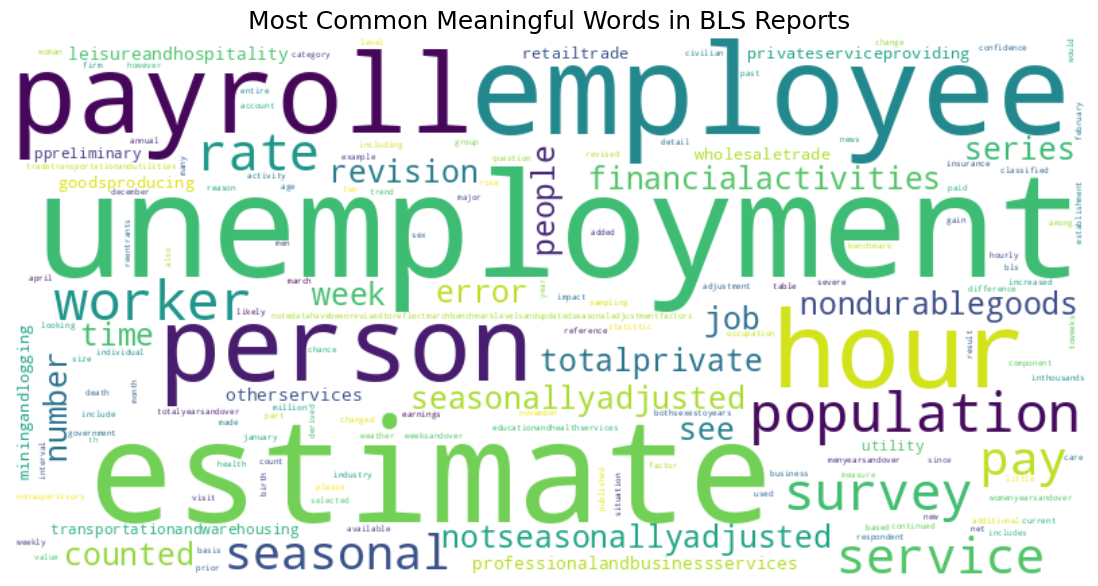

In [ ]:
from collections import Counter                                                 #frequency analysis - word cloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_words = ' '.join(df['clean_text']).split()                                  # Combining all the clean text into one string.



word_counts = Counter(all_words)
print("Top 20 words by frequency:")
print(word_counts.most_common(20))


wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_counts)

# Plot WordCloud
plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Common Meaningful Words in BLS Reports", fontsize=18)
plt.show()

             month  sentiment
0  empsit_02052016   0.031469
1  empsit_03042016   0.033749
2  empsit_04012016   0.032813
3  empsit_05062016   0.026369
4  empsit_06032016   0.018946


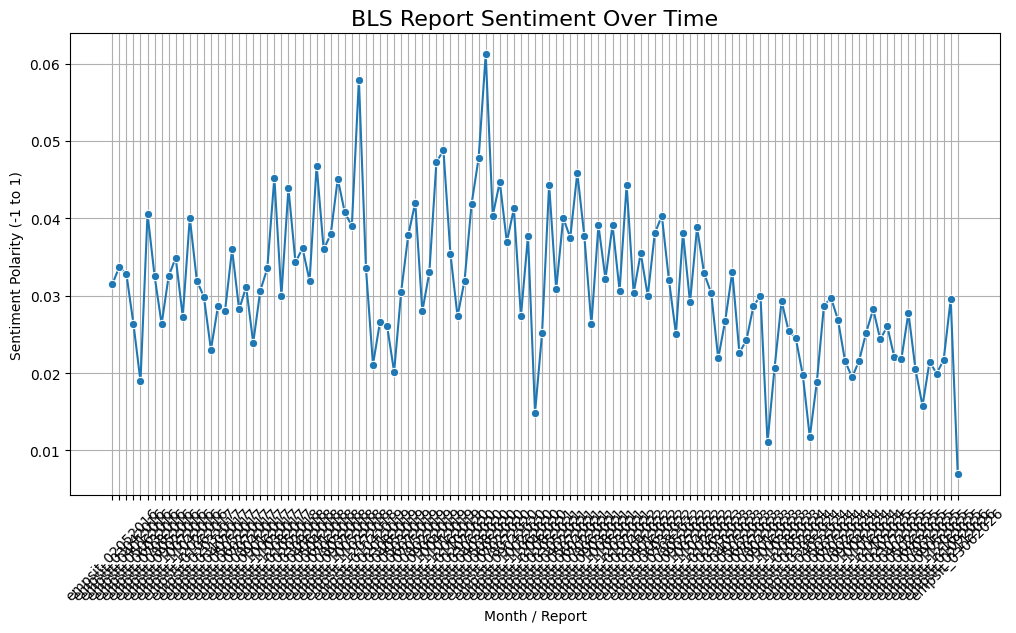

In [ ]:
# --- Sentiment Analysis ---
from textblob import TextBlob
import seaborn as sns
import matplotlib.pyplot as plt

# Function to compute sentiment polarity
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity  # returns -1 (negative) to 1 (positive)

# Apply sentiment analysis
df['sentiment'] = df['clean_text'].apply(get_sentiment)

# Quick check
print(df[['month','sentiment']].head())

# Plot sentiment over time
plt.figure(figsize=(12,6))
sns.lineplot(x='month', y='sentiment', data=df, marker='o')
plt.xticks(rotation=45)
plt.title("BLS Report Sentiment Over Time", fontsize=16)
plt.ylabel("Sentiment Polarity (-1 to 1)")
plt.xlabel("Month / Report")
plt.grid(True)
plt.show()

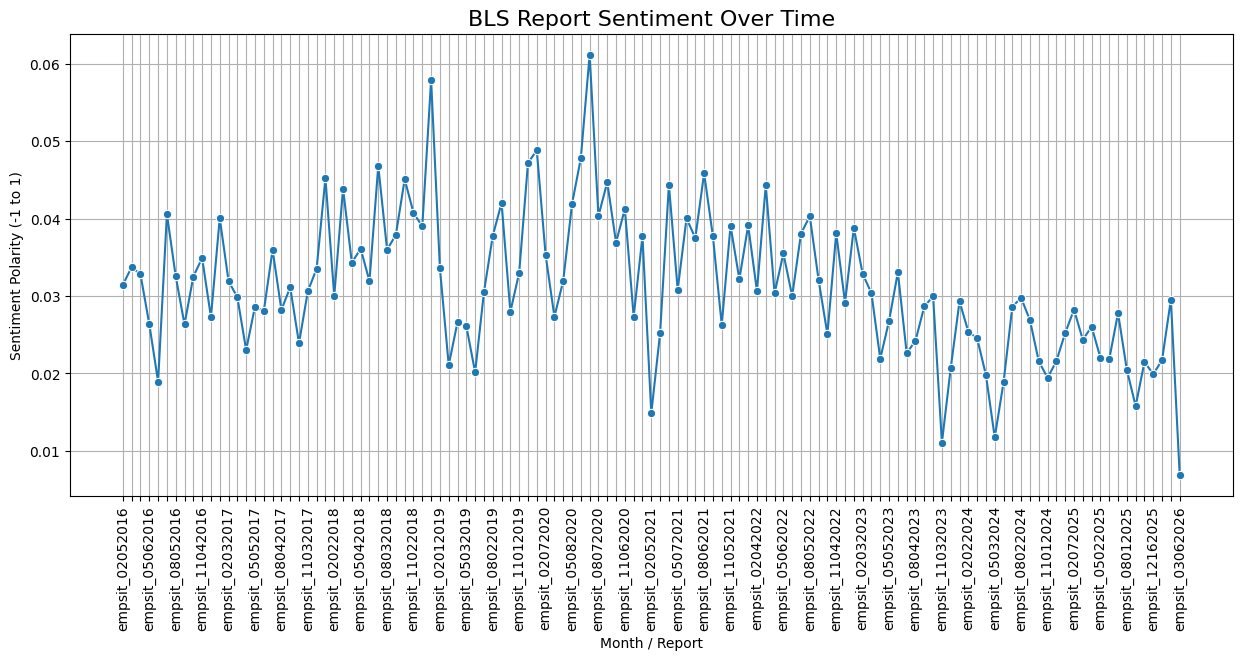

In [ ]:
plt.figure(figsize=(15,6))
sns.lineplot(x='month', y='sentiment', data=df, marker='o')
plt.xticks(rotation=90)  # rotate labels vertically
plt.title("BLS Report Sentiment Over Time", fontsize=16)
plt.ylabel("Sentiment Polarity (-1 to 1)")
plt.xlabel("Month / Report")
plt.grid(True)

# Reduce label clutter: show only every 2nd or 3rd label
for i, label in enumerate(plt.gca().get_xticklabels()):
    if i % 3 != 0:
        label.set_visible(False)

plt.show()

In [ ]:
!pip install gensim
import gensim
from gensim import corpora

# Prepare tokenized text
texts = [doc.split() for doc in df['clean_text']]

# Create dictionary and filter extremes
dictionary = corpora.Dictionary(texts)
dictionary.filter_extremes(no_below=2, no_above=0.8)  # remove very rare and very common words



corpus = [dictionary.doc2bow(text) for text in texts]

lda_model = gensim.models.LdaModel(       #LDA model
    corpus=corpus,
    id2word=dictionary,
    num_topics=4,       # you can adjust this
    passes=10,
    random_state=42
)


print("Top 4 LDA Topics:")                                                      # Displaying the topics
for idx, topic in lda_model.print_topics(num_words=8):
    print(f"Topic {idx+1}: {topic}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 30.0 MB/s eta 0:00:00
Top 4 LDA Topics:
Topic 1: 0.036*"privateeducationandhealthservices" + 0.024*"january" + 0.019*"february" + 0.015*"december" + 0.014*"april" + 0.013*"september" + 0.012*"august" + 0.011*"october"
Topic 2: 0.053*"february" + 0.027*"pandemic" + 0.024*"january" + 0.019*"april" + 0.014*"december" + 0.014*"august" + 0.012*"coronavirus" + 0.012*"higher"
Topic 3: 0.108*"november" + 0.056*"october" + 0.030*"april" + 0.026*"december" + 0.019*"january" + 0.019*"per" + 0.013*"naics" + 0.012*"novp"
Topic 4: 0.030*"september" + 0.024*"february" + 0.023*"august" + 0.019*"january" + 0.018*"december" + 0.014*"earlier" + 0.012*"searched" + 0.011*"per"


In [ ]:
extra_stopwords = [
    'january','february','march','april','may','june','july','august','september',
    'october','november','december','per','naics','novp','earlier','searched'
]

stop_words.update(extra_stopwords)

In [ ]:
import re                                                                       #Final Aggressive Cleaning Function for BLS Reports
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))                                    # Standard stopwords

bls_stopwords = [
    'survey','employment','data','establishment','household','unemployed','employed',
    'table','p','toyears','industry','estimate','percent','civilianlaborforce','payroll',
    'participationrate','employmentpopulationratio','unemploymentrate','month','may',
    'june','july','jan','feb','mar','apr','aug','sept','oct','nov','dec',
    'adjusted','nonfarm','employee','job','change','seasonally','hour','sample',
    'labor','notinlaborforce','person','worker','manufacturing','business',
    'civiliannoninstitutionalpopulation','force','b','information','total','service',
    'year','average','monthly','private','construction','work','yearsandover',
    'status','period','numbersinthousands','sector','durablegoods',
    'production','output','pdf','note','release','material','transmission','embargoed','usdl',
    'january','february','march','april','may','june','july','august','september',
    'october','november','december','per','naics','novp','earlier','searched',
    'edged', 'edt', 'jul', 'jun', 'sep', 'janp', 'decjan',
    'et', 'updated', 'total', 'practice', 'facility', 'product'
]

stop_words.update(bls_stopwords)
lemmatizer = WordNetLemmatizer()

def clean_bls_text_aggressive(text):
    """
    Aggressive cleaning of BLS report text:
    - Lowercase
    - Remove punctuation, numbers, extra spaces
    - Remove stopwords including BLS boilerplate and months
    - Lemmatize words
    """
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)  # remove punctuation
    text = re.sub(r'\d+', '', text)      # remove numbers
    text = re.sub(r'\s+', ' ', text)     # normalize spaces
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return ' '.join(words)

# Apply to your DataFrame
df['clean_text'] = df['report_text'].apply(clean_bls_text_aggressive)

from collections import Counter
all_words = ' '.join(df['clean_text']).split()
print("Top 20 meaningful words after final aggressive cleaning:")
print(Counter(all_words).most_common(20))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Top 20 meaningful words after final aggressive cleaning:
[('unemployment', 3838), ('estimate', 3703), ('employee', 3588), ('payroll', 2905), ('hour', 2719), ('person', 2592), ('population', 2299), ('worker', 2297), ('survey', 2041), ('rate', 1960), ('service', 1875), ('pay', 1790), ('seasonal', 1721), ('notseasonallyadjusted', 1706), ('seasonallyadjusted', 1694), ('nondurablegoods', 1657), ('job', 1603), ('revision', 1552), ('week', 1544), ('time', 1524)]


In [ ]:

import gensim                                         #LDA topic Modelling
from gensim import corpora


texts = [doc.split() for doc in df['clean_text']]

dictionary = corpora.Dictionary(texts)                #creating dictionary and filtering extremes

dictionary.filter_extremes(no_below=2, no_above=0.8)  # remove very rare and very common words

corpus = [dictionary.doc2bow(text) for text in texts]                           #Creating corpus

lda_model = gensim.models.LdaModel( # training the LDA model

    corpus=corpus,
    id2word=dictionary,
    num_topics=4,       # adjust if needed
    passes=10,
    random_state=42
)


print("Top 4 LDA Topics:")
for idx, topic in lda_model.print_topics(num_words=8):
    print(f"Topic {idx+1}: {topic}")

Top 4 LDA Topics:
Topic 1: 0.043*"privateeducationandhealthservices" + 0.012*"independentseasonaladjustmentofthevariousseriesupdatedpopulationcontrolsareintroducedannuallywiththereleaseofjanuarydata" + 0.011*"assistance" + 0.011*"social" + 0.009*"retailer" + 0.009*"notedetailfortheseasonallyadjusteddatashowninthistablewillnotnecessarilyaddtototalunemployedintableabecauseofthe" + 0.009*"componentmanufacturing" + 0.008*"facility"
Topic 2: 0.035*"pandemic" + 0.015*"coronavirus" + 0.015*"higher" + 0.011*"independentseasonaladjustmentofthevariousseriesupdatedpopulationcontrolsareintroducedannuallywiththereleaseofjanuarydata" + 0.009*"supplemental" + 0.008*"lost" + 0.007*"decreased" + 0.007*"notedetailfortheseasonallyadjusteddatashowninthistablewillnotnecessarilyaddtototalunemployedintableabecauseofthe"
Topic 3: 0.009*"product" + 0.008*"machinery" + 0.007*"essentially" + 0.007*"chemical" + 0.007*"decreased" + 0.007*"elderly" + 0.007*"nursingcarefacilities" + 0.007*"miscellaneousdurablegoods"

In [ ]:
df['clean_text'] = df['report_text'].apply(clean_bls_text_aggressive)   #cleaning better

In [ ]:
def clean_long_tokens(text, max_len=20):
    words = text.split()
    words = [w for w in words if len(w) <= max_len]
    return ' '.join(words)

df['clean_text'] = df['clean_text'].apply(lambda x: clean_long_tokens(x, max_len=20))


df['clean_text'] = df['clean_text'].apply(lambda x: ' '.join([w for w in x.split() if len(w) > 1])) # removing remaining single-character tokens

In [ ]:
texts = [doc.split() for doc in df['clean_text']]                               #LDA model
dictionary = corpora.Dictionary(texts)
dictionary.filter_extremes(no_below=2, no_above=0.8)
corpus = [dictionary.doc2bow(text) for text in texts]

lda_model = gensim.models.LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=4,
    passes=10,
    random_state=42
)
print("new Top 4 LDA Topics:")
for idx, topic in lda_model.print_topics(num_words=8):
    print(f"Topic {idx+1}: {topic}")

new Top 4 LDA Topics:
Topic 1: 0.016*"product" + 0.014*"decreased" + 0.013*"machinery" + 0.011*"elderly" + 0.011*"chemical" + 0.011*"sensory" + 0.011*"phone" + 0.011*"voice"
Topic 2: 0.053*"pandemic" + 0.026*"higher" + 0.020*"coronavirus" + 0.011*"lost" + 0.011*"misclassified" + 0.011*"supplemental" + 0.010*"considerably" + 0.010*"assistance"
Topic 3: 0.043*"pandemic" + 0.022*"supplemental" + 0.018*"higher" + 0.016*"teleworked" + 0.014*"far" + 0.013*"coronavirus" + 0.013*"lost" + 0.013*"different"
Topic 4: 0.019*"assistance" + 0.019*"social" + 0.019*"process" + 0.015*"retailer" + 0.012*"facility" + 0.011*"decreased" + 0.011*"shutdown" + 0.010*"shown"


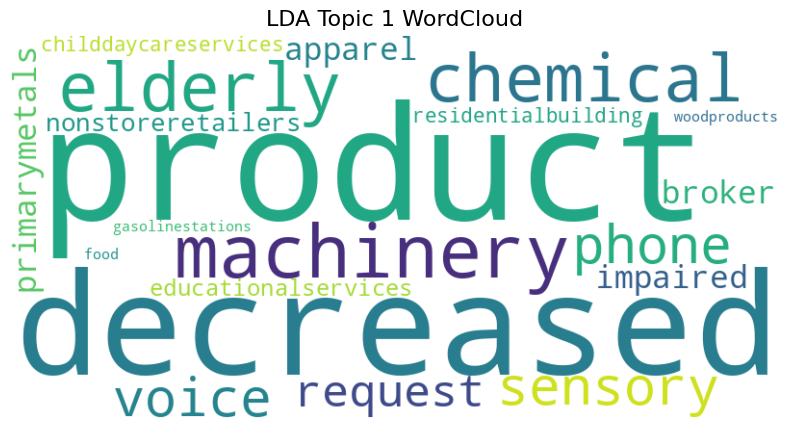

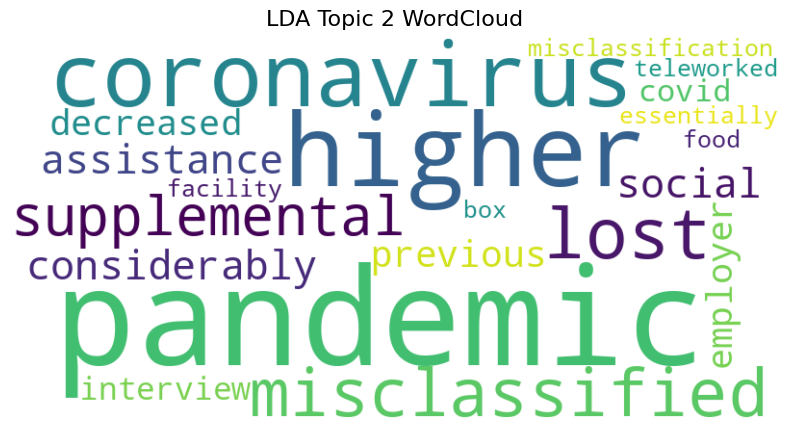

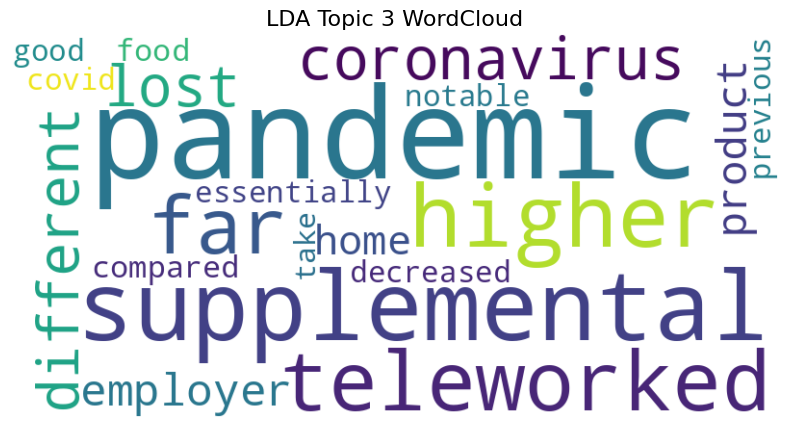

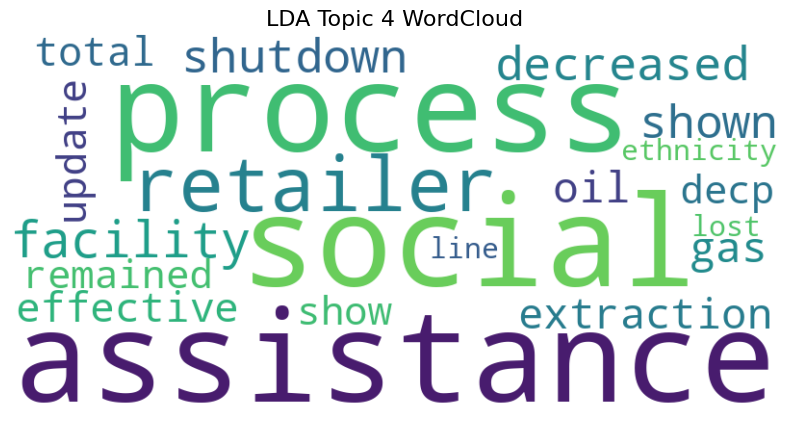

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load FRED CSV
unrate = pd.read_csv('/content/drive/MyDrive/Text_Analytics_Bls_Reports_Group_Project/UNRATE.csv')

# Convert date column
unrate['DATE'] = pd.to_datetime(unrate['observation_date'])

# Keep UNRATE column as is
unrate['UNRATE'] = unrate['UNRATE']

# Sort by date
unrate = unrate.sort_values('DATE').reset_index(drop=True)

# Align with number of reports
num_reports = len(df)
unrate_slice = unrate['UNRATE'].iloc[:num_reports]


plt.figure(figsize=(15,6))
plt.plot(range(num_reports), df['sentiment'], marker='o', label='Report Sentiment')   # Plot sentiment vs unemployment
plt.plot(range(num_reports), unrate_slice, marker='o', label='Unemployment Rate')
plt.xticks(ticks=range(0,num_reports,max(1,num_reports//20)),
           labels=df['month'][::max(1,num_reports//20)], rotation=45)
plt.title("BLS Report Sentiment vs Unemployment Rate", fontsize=16)
plt.ylabel("Value / Polarity")
plt.xlabel("Month / Report")
plt.legend()
plt.grid(True)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Text_Analytics_Bls_Reports_Group_Project/UNRATE.csv'

In [ ]:
import pandas as pd

# unrate = pd.read_csv(unrate)  # your local file
print(unrate.columns)

Index(['observation_date', 'UNRATE'], dtype='object')


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=50)  # top 50 terms
tfidf_matrix = tfidf.fit_transform(df['clean_text'])
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf.get_feature_names_out())
tfidf_df.head()

,adjustment,available,civilian,counted,earnings,employee,error,estimate,financialactivities,goodsproducing,...,survey,time,totalprivate,unemployment,utility,weather,week,weekly,wholesaletrade,worker
0,0.152707,0.093321,0.135740,0.093321,0.067870,0.254512,0.101805,0.356317,0.093321,0.084837,...,0.127256,0.110289,0.101805,0.288447,0.084837,0.076354,0.093321,0.076354,0.084837,0.161191
1,0.072786,0.093582,0.093582,0.114378,0.083184,0.311940,0.124776,0.280746,0.114378,0.103980,...,0.155970,0.135174,0.124776,0.291144,0.103980,0.093582,0.114378,0.093582,0.103980,0.197562
2,0.073964,0.095096,0.095096,0.116229,0.084530,0.316987,0.126795,0.285289,0.116229,0.105662,...,0.158494,0.137361,0.126795,0.285289,0.105662,0.095096,0.116229,0.095096,0.105662,0.200759
3,0.073902,0.095017,0.095017,0.116131,0.084459,0.316722,0.126689,0.285050,0.116131,0.105574,...,0.158361,0.126689,0.126689,0.285050,0.105574,0.095017,0.116131,0.095017,0.105574,0.200591
4,0.071857,0.092388,0.102653,0.112918,0.082122,0.307959,0.123184,0.277163,0.112918,0.102653,...,0.153980,0.123184,0.123184,0.287429,0.102653,0.092388,0.123184,0.092388,0.102653,0.205306


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=50,       # top 50 terms overall
    stop_words='english'   # already removed BLS stopwords, optional extra filtering
)


tfidf_matrix = tfidf.fit_transform(df['clean_text'])            # Fit and transform


tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf.get_feature_names_out()) # Convert to DataFrame


tfidf_sum = tfidf_df.sum(axis=0).sort_values(ascending=False) # Suming up scores to find overall top TF-IDF words
print("Top 20 TF-IDF Terms Across All Reports:")
print(tfidf_sum.head(20))

Top 20 TF-IDF Terms Across All Reports:
unemployment          36.638392
estimate              35.230281
employee              34.460521
payroll               27.888778
person                27.534278
hour                  26.041016
worker                21.991576
population            21.607715
survey                19.530913
rate                  18.572961
service               17.842689
pay                   17.116969
seasonal              16.423594
seasonallyadjusted    16.264755
nondurablegoods       15.909257
job                   15.265314
revision              14.736410
week                  14.708009
time                  14.572035
error                 14.278828
dtype: float64


In [ ]:

df['sentiment_label'] = df['sentiment'].apply(lambda x: 1 if x > 0 else 0)


tfidf_lr = TfidfVectorizer(max_features=500, stop_words='english')
X = tfidf_lr.fit_transform(df['clean_text'])
y = df['sentiment_label']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)


print("\nLogistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: np.int64(1)